# uvfit Tutorial: Gaussian Emission Line Fit with MCMC

This notebook demonstrates **uvfit** end-to-end:
1. Build a 3D Gaussian emission-line cube and add noise to the visibilities.
2. Visualize the cube, peak channel map, and spectrum.
3. Simulate UV data with 200 baselines.
4. Fit a template model with **wrong** initial guesses and recover the true parameters.
5. Plot the final (no-noise) model and the MCMC posterior (corner plot + correlation matrix).

## Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

from uvfit import UVDataset, TemplateCubeModel, Fitter, FitResult

# Optional: for MCMC corner plot and correlation matrix
try:
    import corner
    HAS_CORNER = True
except ImportError:
    HAS_CORNER = False
    print("Install 'corner' for corner plot: pip install corner")

## 1. Build the Gaussian emission-line cube

We create a 3D cube (n_chan × ny × nx) with a Gaussian in space and in velocity. True parameters: centered at (0, 0), peak in channel 8, flux scale 1. This cube will be our "true" sky; we add pixel noise to get a **noisy template** (realistic case), then fit a template model with parameters dx, dy, dv, flux_scale—true values are (0, 0, 0, 1). At the end we show the best-fit model cube.

In [2]:
def make_gaussian_cube(nx=32, ny=32, n_chan=16, cell_size=0.5, x0=0.0, y0=0.0,
                       fwhm_spatial=2.0, fwhm_spectral=4.0, v0_chan=8.0, peak_flux=1.0):
    """Create a 3D Gaussian emission cube. Returns cube (n_chan, ny, nx) and truth dict."""
    sigma_s = fwhm_spatial / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    sigma_v = fwhm_spectral / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    x = (np.arange(nx) - nx / 2 + 0.5) * cell_size
    y = (np.arange(ny) - ny / 2 + 0.5) * cell_size
    xx, yy = np.meshgrid(x, y)
    spatial = peak_flux * np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2.0 * sigma_s**2))
    cube = np.zeros((n_chan, ny, nx), dtype=np.float64)
    for ch in range(n_chan):
        cube[ch] = spatial * np.exp(-((ch - v0_chan) ** 2) / (2.0 * sigma_v**2))
    truth = {"x0": x0, "y0": y0, "fwhm_spatial": fwhm_spatial, "fwhm_spectral": fwhm_spectral,
             "v0_chan": v0_chan, "peak_flux": peak_flux, "cell_size": cell_size,
             "nx": nx, "ny": ny, "n_chan": n_chan}
    return cube, truth

nx, ny, n_chan = 32, 32, 16
cell_size = 0.5
cube_true, truth = make_gaussian_cube(nx=nx, ny=ny, n_chan=n_chan, cell_size=cell_size)
# Noisy template (realistic: fit observation with a model derived from a noisy cube)
rng_template = np.random.default_rng(43)
sigma_pixel = 0.05 * np.std(cube_true)
template_cube = np.maximum(
    cube_true + sigma_pixel * rng_template.standard_normal(cube_true.shape), 0.0
).astype(np.float64)
print(f"Cube shape: {cube_true.shape}")
print(f"Noisy template: sigma_pixel = {sigma_pixel:.4f} (5% of cube std)")
print(f"True (sky) params: x0={truth['x0']}, y0={truth['y0']}, v0_chan={truth['v0_chan']}, peak_flux={truth['peak_flux']}")

Cube shape: (16, 32, 32)
True (sky) params: x0=0.0, y0=0.0, v0_chan=8.0, peak_flux=1.0


## 2. Visualize: cube, peak channel, and spectrum

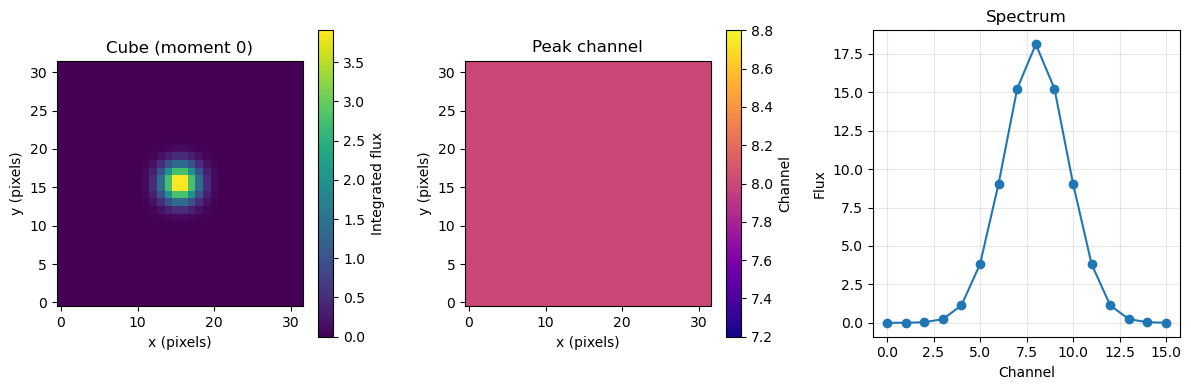

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Left: integrated intensity (moment 0) as a 2D map
moment0 = np.sum(cube_true, axis=0)
im0 = axes[0].imshow(moment0, origin="lower", cmap="viridis")
axes[0].set_title("Cube (moment 0)")
axes[0].set_xlabel("x (pixels)")
axes[0].set_ylabel("y (pixels)")
plt.colorbar(im0, ax=axes[0], label="Integrated flux")

# Middle: peak channel map (channel with max flux per pixel)
peak_ch = np.argmax(cube_true, axis=0)
im1 = axes[1].imshow(peak_ch, origin="lower", cmap="plasma")
axes[1].set_title("Peak channel")
axes[1].set_xlabel("x (pixels)")
axes[1].set_ylabel("y (pixels)")
plt.colorbar(im1, ax=axes[1], label="Channel")

# Right: spectrum (sum over spatial pixels per channel)
spectrum = np.sum(cube_true, axis=(1, 2))
axes[2].plot(np.arange(n_chan), spectrum, "o-")
axes[2].set_title("Spectrum")
axes[2].set_xlabel("Channel")
axes[2].set_ylabel("Flux")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Simulate UV data with 200 baselines (noise set for peak SNR = 10)

We FFT each channel, sample at random (u, v) points, then set the noise level so that **peak SNR = 10** (peak |V| / σ = 10). Weights = 1/σ².

In [4]:
def simulate_visibilities(cube, cell_size, n_baselines=200, noise_sigma=None, target_peak_snr=None, seed=42):
    """Simulate observed visibilities at random (u,v) with additive noise.
    If target_peak_snr is set, noise_sigma is ignored and set so peak |V| / sigma = target_peak_snr."""
    rng = np.random.default_rng(seed)
    n_chan, ny, nx = cube.shape
    cell_rad = cell_size * np.pi / (180.0 * 3600.0)
    u_grid = np.fft.fftshift(np.fft.fftfreq(nx, d=cell_rad))
    v_grid = np.fft.fftshift(np.fft.fftfreq(ny, d=cell_rad))
    u_max, v_max = u_grid.max() * 0.8, v_grid.max() * 0.8
    u = rng.uniform(-u_max, u_max, size=n_baselines)
    v = rng.uniform(-v_max, v_max, size=n_baselines)
    vis = np.zeros((n_baselines, n_chan), dtype=np.complex128)
    for ch in range(n_chan):
        ft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(cube[ch])))
        interp_re = RegularGridInterpolator((v_grid, u_grid), ft.real, method="linear", bounds_error=False, fill_value=0.0)
        interp_im = RegularGridInterpolator((v_grid, u_grid), ft.imag, method="linear", bounds_error=False, fill_value=0.0)
        pts = np.stack([v, u], axis=-1)
        vis[:, ch] = interp_re(pts) + 1j * interp_im(pts)
    if target_peak_snr is not None:
        peak_amp = np.max(np.abs(vis))
        noise_sigma = peak_amp / target_peak_snr
        print(f"Target peak SNR = {target_peak_snr} → noise_sigma = {noise_sigma:.6f} (peak |V| = {peak_amp:.6f})")
    elif noise_sigma is None:
        noise_sigma = 0.01
    noise = noise_sigma * (rng.standard_normal(vis.shape) + 1j * rng.standard_normal(vis.shape))
    vis_noisy = vis + noise
    weights = np.full_like(vis_noisy.real, 1.0 / noise_sigma**2)
    freqs = 230.538e9 + (np.arange(n_chan) - n_chan / 2) * 1e6
    return u, v, vis_noisy, weights, freqs

n_baselines = 200
peak_snr = 10
u, v, vis_noisy, weights, freqs = simulate_visibilities(
    cube_true, cell_size, n_baselines=n_baselines, target_peak_snr=peak_snr
)
uvdata = UVDataset.from_mock(u=u, v=v, vis=vis_noisy, weights=weights, freqs=freqs)
print(f"UV data: {uvdata.n_baseline} baselines × {uvdata.n_chan} channels")

Target peak SNR = 10 → noise_sigma = 1.648824 (peak |V| = 16.488240)
UV data: 200 baselines × 16 channels


## 3b. UV data distributions and UV-plot (deprojected visibilities)

We visualize the **UV coverage** (distributions of u, v and visibility amplitude) and a **UV-plot**: visibility amplitude vs. baseline length (deprojected, i.e. binned by \(\sqrt{u^2 + v^2}\)).

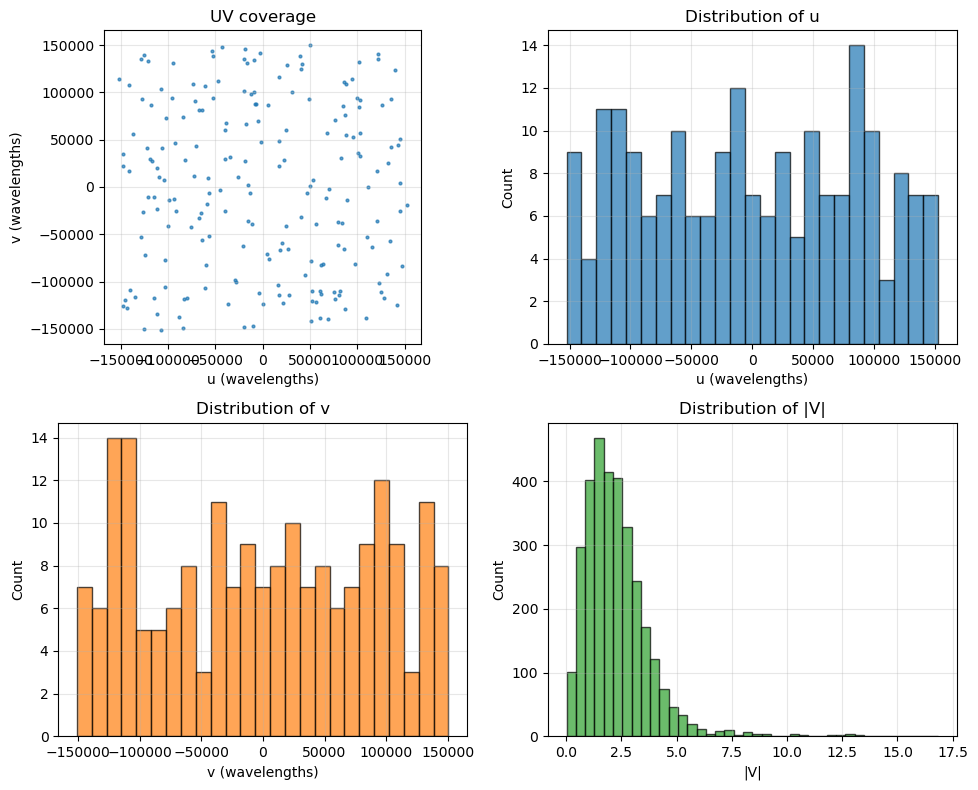

In [18]:
# UV data distributions
fig_uv, axes_uv = plt.subplots(2, 2, figsize=(10, 8))

# (u, v) coverage
axes_uv[0, 0].scatter(uvdata.u, uvdata.v, s=4, alpha=0.7)
axes_uv[0, 0].set_xlabel("u (wavelengths)")
axes_uv[0, 0].set_ylabel("v (wavelengths)")
axes_uv[0, 0].set_title("UV coverage")
axes_uv[0, 0].set_aspect("equal")
axes_uv[0, 0].grid(True, alpha=0.3)

# Histogram of u
axes_uv[0, 1].hist(uvdata.u, bins=25, edgecolor="k", alpha=0.7)
axes_uv[0, 1].set_xlabel("u (wavelengths)")
axes_uv[0, 1].set_ylabel("Count")
axes_uv[0, 1].set_title("Distribution of u")
axes_uv[0, 1].grid(True, alpha=0.3)

# Histogram of v
axes_uv[1, 0].hist(uvdata.v, bins=25, edgecolor="k", alpha=0.7, color="C1")
axes_uv[1, 0].set_xlabel("v (wavelengths)")
axes_uv[1, 0].set_ylabel("Count")
axes_uv[1, 0].set_title("Distribution of v")
axes_uv[1, 0].grid(True, alpha=0.3)

# Visibility amplitude distribution (all baselines and channels)
amp = np.abs(uvdata.vis_data).ravel()
axes_uv[1, 1].hist(amp, bins=40, edgecolor="k", alpha=0.7, color="C2")
axes_uv[1, 1].set_xlabel("|V|")
axes_uv[1, 1].set_ylabel("Count")
axes_uv[1, 1].set_title("Distribution of |V|")
axes_uv[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Fit: gradient (L-BFGS-B) then MCMC

We use a **noisy** version of the true cube as the template (realistic: observation is fit with a model derived from a noisy cube). The template model has parameters (dx, dy, dv, flux_scale); the true values are (0, 0, 0, 1). We start from deliberately wrong initial guesses, first run a **gradient-based fit (L-BFGS-B)** to find a good starting point, then run **MCMC (emcee)** to recover the posterior and uncertainties.

### 4a. Gradient fit (L-BFGS-B)

Minimize χ² with scipy’s L-BFGS-B to get a point estimate from the wrong initial guesses.

In [7]:
# Template model and fitter
model = TemplateCubeModel(template_cube=template_cube, cell_size_arcsec=cell_size)
fitter = Fitter(uvdata=uvdata, forward_model=model)

# Deliberately wrong initial guesses (truth: dx=0, dy=0, dv=0, flux_scale=1)
initial_params = {
    "dx": 0.4,
    "dy": -0.3,
    "dv": 2.0,
    "flux_scale": 1.2,
}
print("Initial (wrong) params:", initial_params)
print("Running gradient fit (L-BFGS-B)...")
result_grad = fitter.fit(initial_params=initial_params, method="L-BFGS-B")
print("Gradient fit result:", result_grad.params)
print("Reduced χ²:", result_grad.reduced_chi2)

Initial (wrong) params: {'dx': 0.4, 'dy': -0.3, 'dv': 2.0, 'flux_scale': 1.2}
Running gradient fit (L-BFGS-B)...
Gradient fit result: {'dx': 0.022679172586011237, 'dy': -0.010392596845608565, 'dv': 0.005781422672127342, 'flux_scale': 0.9686320632271289}
Reduced χ²: 1.0171329715409467


### 4b. MCMC (emcee)

Use the gradient best-fit as the starting point for MCMC to sample the full posterior.

In [8]:
# Start MCMC from the gradient best-fit (model and fitter already defined above)
print("Running MCMC (emcee) from gradient best-fit...")
result = fitter.fit(
    initial_params=result_grad.params,
    method="emcee",
    n_walkers=32,
    n_steps=400,
    n_burn=100,
)
print("Done.")

Running MCMC (emcee) from gradient best-fit...


100%|██████████| 400/400 [01:10<00:00,  5.69it/s]


Done.


### UV-plot: Data and best-fit model

Deprojected visibilities (Re(V) and Im(V) vs uv-distance in kλ) using **uvplot**, with the best-fit model overlaid.

Masking 0 uv bins


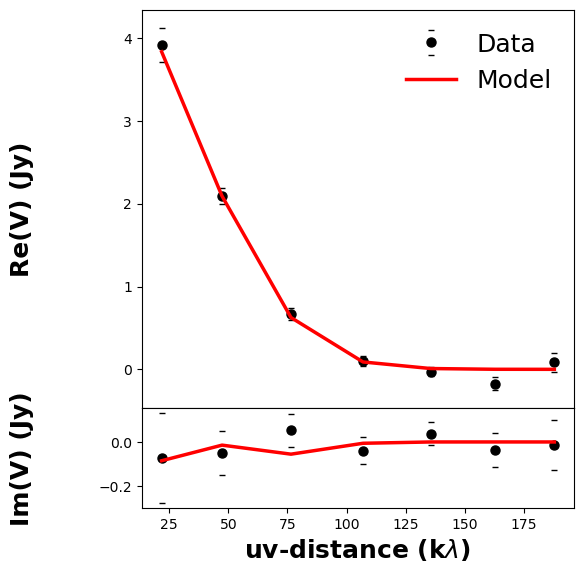

In [9]:
# UV-plot with uvplot: Data + best-fit Model (Re and Im vs uv-distance)
from uvplot import UVTable, COLUMNS_V0

# Data table (same as in section 3b)
u_flat = np.repeat(uvdata.u, uvdata.n_chan)
v_flat = np.repeat(uvdata.v, uvdata.n_chan)
re_flat = uvdata.vis_data.real.ravel()
im_flat = uvdata.vis_data.imag.ravel()
w_flat = uvdata.weights.ravel()
uv_table = UVTable(uvtable=[u_flat, v_flat, re_flat, im_flat, w_flat], columns=COLUMNS_V0, wle=1.0)

# Model visibilities at best-fit (use MCMC result if available, else gradient result)
try:
    best = result.params
except NameError:
    best = result_grad.params
cube_best = model.generate_cube(best)
model_vis = fitter.engine.degrid(cube=cube_best, u=uvdata.u, v=uvdata.v, freqs=uvdata.freqs)
re_mod = model_vis.real.ravel()
im_mod = model_vis.imag.ravel()
uv_mod = UVTable(uvtable=[u_flat, v_flat, re_mod, im_mod, w_flat], columns=COLUMNS_V0, wle=1.0)

uvbin_size = 30e3  # 30 kλ
axes = uv_table.plot(label="Data", uvbin_size=uvbin_size, verbose=False)
uv_mod.plot(label="Model", uvbin_size=uvbin_size, axes=axes, yerr=False, linestyle="-", color="r")
plt.show()

## 5. Recovered parameters and show the model

We compare best-fit (MAP) parameters to the true values, then plot the **best-fit model cube**—the template (noisy) shifted and scaled at the fitted parameters—alongside the true cube for comparison.

Recovered (MAP) params: {'dx': 0.021487247604619487, 'dy': -0.008876618859699356, 'dv': 0.00552771882304131, 'flux_scale': 0.9676650383720896}
True (template) params: {'dx': 0.0, 'dy': 0.0, 'dv': 0.0, 'flux_scale': 1.0}
Reduced χ²: 1.017134577491226


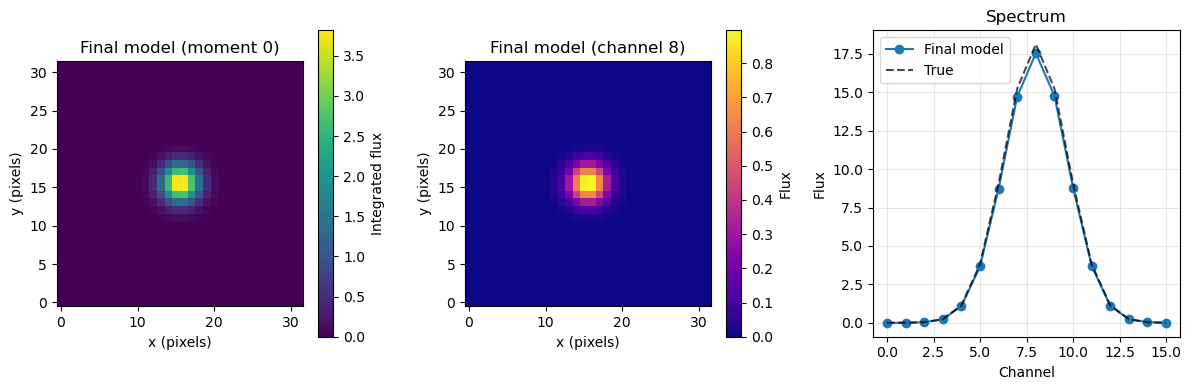

In [14]:
true_template_params = {"dx": 0.0, "dy": 0.0, "dv": 0.0, "flux_scale": 1.0}
print("Recovered (MAP) params:", result.params)
print("True (template) params:", true_template_params)
print("Reduced χ²:", result.reduced_chi2)

# Final model cube at best-fit params (no noise)
cube_final = model.generate_cube(result.params)

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
moment0_final = np.sum(cube_final, axis=0)
im0 = axes2[0].imshow(moment0_final, origin="lower", cmap="viridis")
axes2[0].set_title("Final model (moment 0)")
axes2[0].set_xlabel("x (pixels)")
axes2[0].set_ylabel("y (pixels)")
plt.colorbar(im0, ax=axes2[0], label="Integrated flux")

# Image at the peak channel (channel where integrated flux is max)
ch_peak_final = int(np.argmax(np.sum(cube_final, axis=(1, 2))))
im1 = axes2[1].imshow(cube_final[ch_peak_final], origin="lower", cmap="plasma")
axes2[1].set_title(f"Final model (channel {ch_peak_final})")
axes2[1].set_xlabel("x (pixels)")
axes2[1].set_ylabel("y (pixels)")
plt.colorbar(im1, ax=axes2[1], label="Flux")

spec_final = np.sum(cube_final, axis=(1, 2))
axes2[2].plot(np.arange(n_chan), spec_final, "o-", label="Final model")
axes2[2].plot(np.arange(n_chan), np.sum(cube_true, axis=(1, 2)), "k--", alpha=0.7, label="True")
axes2[2].set_title("Spectrum")
axes2[2].set_xlabel("Channel")
axes2[2].set_ylabel("Flux")
axes2[2].legend()
axes2[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Posterior distribution and correlation matrix

We use the MCMC chains (after burn-in) to plot the **posterior distribution** (corner plot) and the **correlation matrix** between parameters.

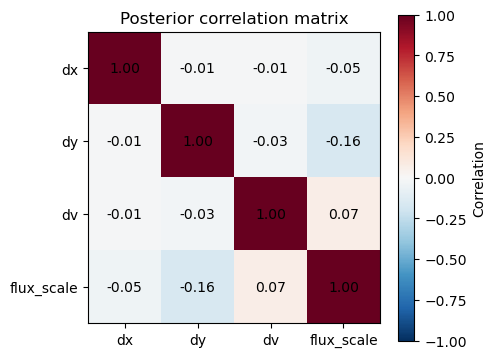

In [15]:
param_names = list(result.params.keys())
# Flatten chains: (n_steps, n_walkers, n_params) -> (n_samples, n_params)
samples = result.chains.reshape(-1, result.chains.shape[-1])

# Correlation matrix from posterior samples
corr = np.corrcoef(samples.T)
fig_corr, ax_corr = plt.subplots(figsize=(5, 4))
im = ax_corr.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax_corr.set_xticks(range(len(param_names)))
ax_corr.set_yticks(range(len(param_names)))
ax_corr.set_xticklabels(param_names)
ax_corr.set_yticklabels(param_names)
for i in range(len(param_names)):
    for j in range(len(param_names)):
        ax_corr.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=10)
plt.colorbar(im, ax=ax_corr, label="Correlation")
ax_corr.set_title("Posterior correlation matrix")
plt.tight_layout()
plt.show()

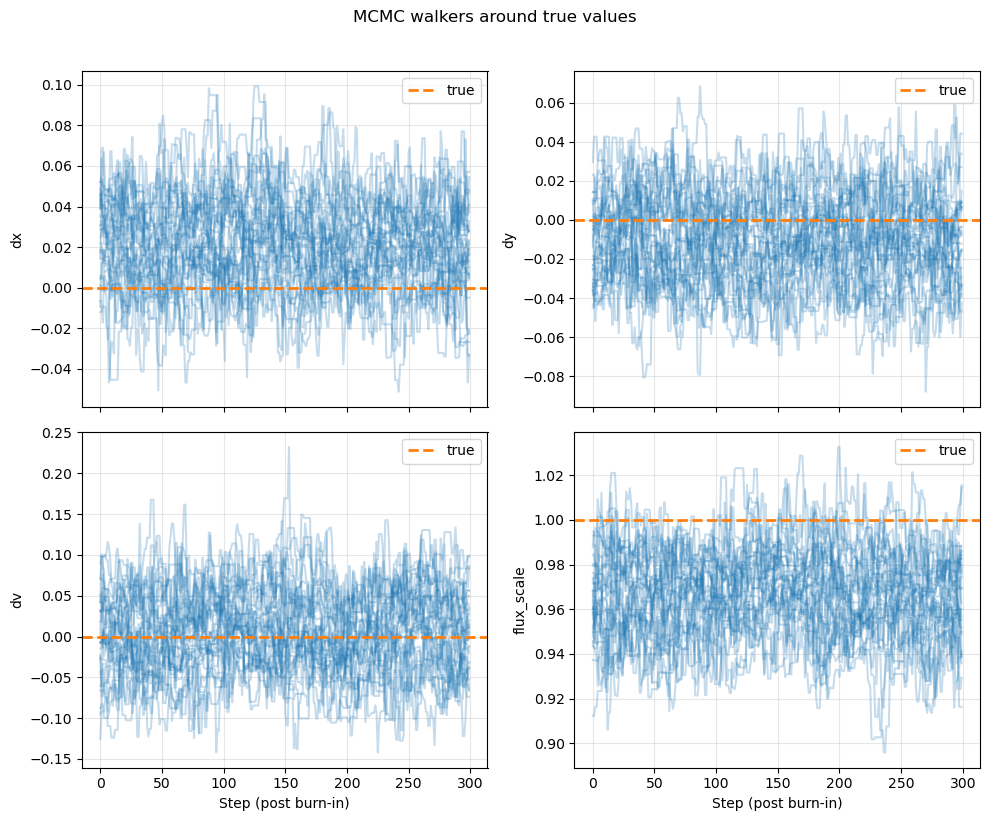

In [16]:
# Walker evolution: each parameter vs step, with true values
param_names = list(result.params.keys())
true_values = [0.0, 0.0, 0.0, 1.0]  # dx, dy, dv, flux_scale
chains = result.chains  # (n_steps, n_walkers, n_params)
n_steps = chains.shape[0]

fig_walk, axes_walk = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
axes_walk = axes_walk.ravel()
for i, (name, true_val) in enumerate(zip(param_names, true_values)):
    for w in range(chains.shape[1]):
        axes_walk[i].plot(np.arange(n_steps), chains[:, w, i], color="C0", alpha=0.25)
    axes_walk[i].axhline(true_val, color="C1", ls="--", lw=2, label="true")
    axes_walk[i].set_ylabel(name)
    axes_walk[i].legend(loc="upper right")
    axes_walk[i].grid(True, alpha=0.3)
axes_walk[2].set_xlabel("Step (post burn-in)")
axes_walk[3].set_xlabel("Step (post burn-in)")
fig_walk.suptitle("MCMC walkers around true values", y=1.02)
plt.tight_layout()
plt.show()

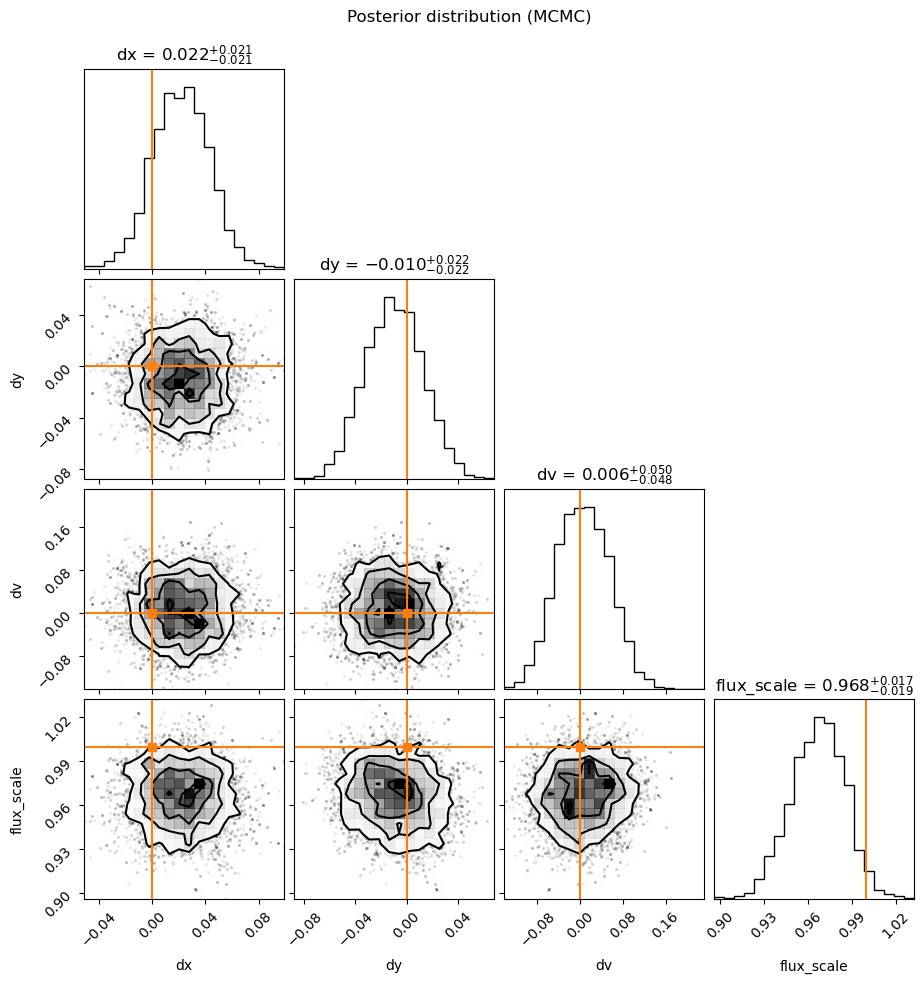

In [17]:
# Corner plot (posterior distributions)
if HAS_CORNER:
    fig_corner = corner.corner(samples, labels=param_names, truths=[0, 0, 0, 1],
                               truth_color="C1", show_titles=True, title_fmt=".3f")
    fig_corner.suptitle("Posterior distribution (MCMC)", y=1.02)
    plt.show()
else:
    # Fallback: 1D marginals
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))
    axes = axes.ravel()
    for i, name in enumerate(param_names):
        axes[i].hist(samples[:, i], bins=50, density=True, alpha=0.7, color="steelblue", edgecolor="none")
        axes[i].axvline([0, 0, 0, 1][i], color="C1", ls="--", label="truth")
        axes[i].set_xlabel(name)
        axes[i].set_ylabel("Density")
        axes[i].legend()
    plt.suptitle("Posterior marginals (no corner package)")
    plt.tight_layout()
    plt.show()